In [233]:
!uv pip install numpy pandas matplotlib nltk pythainlp scikit-learn

Using Python 3.11.15 environment at: /home/kami/Projects/NLP/.venv
Checked 6 packages in 1ms


In [234]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /home/kami/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/kami/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/kami/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [235]:
train = pd.read_csv('./financial-news-data/financial-news-train.csv', encoding='utf-8')
test = pd.read_csv('./financial-news-data/financial-news-test.csv', encoding='utf-8')

In [236]:
def clean_text_dataframe(df, drop_duplicates=True):
    # Lowercase
    df['text'] = df['text'].str.lower()

    # Remove quotes
    df['text'] = df['text'].str.replace('"', '', regex=False)

    # Remove links
    df['text'] = df['text'].str.replace(r'https?://\S+', '', regex=True)

    # Remove words that don't start with an alphabetic character
    # Too destructive
    # df['text'] = df['text'].str.replace(r'\b[^a-z\s]\S*', '', regex=True)

    # Remove non-alphabetic characters
    df['text'] = df['text'].str.replace(r'[^a-z\s]', '', regex=True)

    # Normalize whitespace after removals
    df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

    if drop_duplicates:
        df.drop_duplicates(subset=['text'], inplace=True)

    # NLTK remove stopwods
    stop_words = set(stopwords.words('english'))
    df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

In [237]:
# Show full text
pd.set_option('display.max_colwidth', None)

clean_text_dataframe(train)
clean_text_dataframe(test, drop_duplicates=False)

train

,text,label
0,thursdays biggest analyst calls apple amazon tesla palantir docusign exxon amp,Analyst Update
1,buy las vegas sands travel singapore builds wells fargo says,Analyst Update
2,piper sandler downgrades docusign sell citing elevated risks amid ceo transition,Analyst Update
3,analysts react teslas latest earnings break whats next electric car maker,Analyst Update
4,netflix peers set return growth analysts say giving one stock upside,Analyst Update
...,...,...
16984,china developers face bn wall dollar bond payments second half,Treasuries | Corporate Debt
16985,kfw credit line uniper could raised bln eur handelsblatt,Treasuries | Corporate Debt
16987,russian sells bln roubles oneyear repo auction,Treasuries | Corporate Debt
16988,global esg bond issuance posts h dip supranationals cut back,Treasuries | Corporate Debt


In [238]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_train = vectorizer.fit_transform(train['text'])
X_test = vectorizer.transform(test['text'])

In [239]:
vectorizer.get_feature_names_out()

array(['aa', 'aad', 'aaic', ..., 'zynx', 'zyus', 'zyversa'],
      shape=(23252,), dtype=object)

In [240]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train = encoder.fit_transform(train['label'])
y_test = encoder.transform(test['label'])

In [241]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, fit_intercept=False, random_state=4233)
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",4233
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [242]:
pred = model.predict(X_test)

In [243]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

#Q1

print("Classification Report:")
print(classification_report(
    y_test,
    pred,
    target_names=encoder.classes_,
    digits=3,
    zero_division=0
))

Classification Report:
                             precision    recall  f1-score   support

             Analyst Update      0.891     0.671     0.766        73
     Company | Product News      0.808     0.877     0.841       852
                 Currencies      0.885     0.719     0.793        32
                   Dividend      0.979     0.979     0.979        97
                   Earnings      0.906     0.917     0.912       242
               Energy | Oil      0.807     0.801     0.804       146
        Fed | Central Banks      0.871     0.850     0.861       214
                 Financials      0.869     0.831     0.850       160
     General News | Opinion      0.743     0.738     0.740       336
  Gold | Metals | Materials      0.556     0.769     0.645        13
                        IPO      0.818     0.643     0.720        14
         Legal | Regulation      0.923     0.807     0.861       119
          M&A | Investments      0.816     0.690     0.748       116
          

In [244]:
model_weights = pd.DataFrame(model.coef_, columns=vectorizer.get_feature_names_out(), index=encoder.classes_).T
model_weights

,Analyst Update,Company | Product News,Currencies,Dividend,Earnings,Energy | Oil,Fed | Central Banks,Financials,General News | Opinion,Gold | Metals | Materials,IPO,Legal | Regulation,M&A | Investments,Macro,Markets,Personnel Change,Politics,Stock Commentary,Stock Movement,Treasuries | Corporate Debt
aa,0.481437,-0.050855,-0.041077,-0.025943,0.011917,-0.046484,-0.031920,0.044274,-0.051483,-0.041798,-0.022393,-0.029572,-0.025806,-0.186024,-0.106725,-0.024884,-0.029714,0.245443,-0.020175,-0.048219
aad,-0.001979,0.121015,-0.003278,-0.002965,-0.005477,-0.003021,-0.002969,-0.002818,-0.031166,-0.003478,-0.002929,-0.006852,-0.003748,-0.001568,-0.002956,-0.034465,-0.002919,-0.001920,-0.003865,-0.002645
aaic,-0.001046,-0.050780,-0.001230,-0.000599,-0.001979,-0.001647,-0.001537,-0.000733,-0.008601,-0.001143,-0.000819,-0.000621,-0.001092,-0.000815,-0.001853,-0.001316,-0.001267,0.108514,-0.030315,-0.001121
aaii,-0.000298,-0.001164,-0.002570,-0.000446,-0.002185,-0.000830,-0.001312,-0.000468,-0.000447,-0.001141,-0.000396,-0.000303,-0.000899,0.108576,-0.000480,-0.000447,-0.000499,-0.093177,-0.000629,-0.000883
aal,-0.167283,0.223879,-0.049826,-0.040196,0.287879,-0.240411,-0.064314,0.053525,-0.216619,-0.046447,-0.044868,-0.057605,-0.077472,-0.257954,-0.088546,-0.104672,-0.066011,0.676365,0.339732,-0.059156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zynerba,-0.000337,-0.004303,-0.000344,-0.000349,-0.000305,-0.000397,-0.000368,-0.000425,-0.001491,-0.000320,-0.000336,-0.001486,-0.009835,-0.000370,-0.000369,-0.000357,-0.000332,-0.000410,0.022692,-0.000557
zynlonta,-0.000266,0.006544,-0.000267,-0.000403,-0.000310,-0.000270,-0.000276,-0.000352,-0.000297,-0.000266,-0.000263,-0.000341,-0.000410,-0.000280,-0.000273,-0.000703,-0.000296,-0.000287,-0.000642,-0.000342
zynx,-0.002794,0.158725,-0.001474,-0.002788,-0.002251,-0.001618,-0.001328,-0.005408,-0.038212,-0.002035,-0.003213,-0.005105,-0.037523,-0.017150,-0.001587,-0.004633,-0.004003,-0.020167,-0.004151,-0.003285
zyus,-0.006487,0.360152,-0.004915,-0.060730,-0.004924,-0.120181,-0.008918,-0.007073,-0.033288,-0.005224,-0.006390,-0.012112,-0.017321,-0.013041,-0.006581,-0.008758,-0.003540,-0.012583,-0.016914,-0.011173


In [246]:
model_weights.to_csv('model_weights.csv', index=True)

In [247]:
#Q2

best_weights = []
worst_weights = []

# Get 2 best performing labels based on F1 score
f1_scores = f1_score(y_test, pred, average=None)
best_labels = f1_scores.argsort()[::-1][:2]
best_labels_name = encoder.inverse_transform(best_labels)

print(best_labels_name)

['Dividend' 'Earnings']


In [248]:
# Calculate exact-token feature coverage and purity from the same
# bag-of-words matrix used to train the classifier.
def calculate_feature_coverage_and_purity(label, feature):
    label_mask = train['label'].eq(label).to_numpy()
    feature_index = vectorizer.vocabulary_.get(feature)

    if feature_index is None or not label_mask.any():
        return 0.0, 0.0

    feature_present = X_train[:, feature_index].toarray().ravel() > 0
    coverage = feature_present[label_mask].mean() * 100
    purity = label_mask[feature_present].mean() * 100 if feature_present.any() else 0.0

    return coverage, purity

In [251]:
for label in best_labels_name:
    print(f"\nTop 10 features for label '{label}':")

    # Show each feature's weight, exact-token coverage, and feature purity.
    top_features = model_weights[label].sort_values(ascending=False).head(10)

    top_features_cov_purity = [(weight, *calculate_feature_coverage_and_purity(label, feature)) for feature, weight in top_features.items()]
    top_features_df = pd.DataFrame(top_features_cov_purity, columns=['Weight', 'Coverage (%)', 'Feature Purity (%)'], index=top_features.index)
    print(top_features_df)
    best_weights.append(top_features.tolist())


Top 10 features for label 'Dividend':
                 Weight  Coverage (%)  Specificity (%)
dividend       4.754010     79.387187        80.508475
distribution   2.558056     21.169916        62.809917
declares       2.529116     68.523677        96.093750
distributions  1.399710      1.949861        53.846154
dividends      1.284329      2.228412        47.058824
exdividend     1.197050      1.114206        57.142857
quarterly      1.197049     16.434540        56.190476
trust          1.145425     10.306407        30.327869
announces      1.117947      9.749304         5.477308
preferred      0.951008      3.064067        42.307692

Top 10 features for label 'Earnings':
              Weight  Coverage (%)  Specificity (%)
earnings    4.853309     64.681725        67.961165
results     3.687123     57.084189        82.861401
preview     1.847824      7.597536        88.095238
quarter     1.805104     46.714579        59.090909
call        1.607313     42.915811        63.429439
upcom

In [252]:
# Q3

# Get 2 worst performing labels based on F1 score
worst_labels = f1_scores.argsort()[::-1][-2:]
worst_labels_name = encoder.inverse_transform(worst_labels)

print(worst_labels_name)

for label in worst_labels_name:
    print(f"\nTop 10 features for label '{label}':")
    top_features = model_weights[label].sort_values(ascending=False).head(10)
    top_features_cov_purity = [(weight, *calculate_feature_coverage_and_purity(label, feature)) for feature, weight in top_features.items()]
    top_features_df = pd.DataFrame(top_features_cov_purity, columns=['Weight', 'Coverage (%)', 'Feature Purity (%)'], index=top_features.index)
    print(top_features_df)
    
    worst_weights.append(top_features.tolist())

['IPO' 'Gold | Metals | Materials']

Top 10 features for label 'IPO':
           Weight  Coverage (%)  Specificity (%)
ipo      4.289725     80.952381        54.838710
ipos     1.243693     11.904762        83.333333
public   1.059201     16.666667         4.046243
spac     0.838820      9.523810         3.361345
go       0.744646     21.428571         0.655499
kong     0.699687     14.285714        20.689655
listing  0.674794     14.285714        12.765957
hong     0.649832     14.285714        19.354839
dubai    0.626575      4.761905        22.222222
porsche  0.605521      9.523810        44.444444

Top 10 features for label 'Gold | Metals | Materials':
                 Weight  Coverage (%)  Specificity (%)
gold           3.454973     75.862069        20.853081
metals         1.609365      6.896552        21.052632
copper         1.598625     15.517241        26.470588
dollar         0.983159     24.137931         6.334842
nickel         0.796143      3.448276        28.571429
gld  

In [253]:
# Get top 3 of each label
for label in encoder.classes_:
    print(f"\nTop 3 features for label '{label}':")
    top_features = model_weights[label].sort_values(ascending=False).head(3)
    print(top_features)


Top 3 features for label 'Analyst Update':
downgrades    2.582110
analyst       2.191438
ratings       1.804666
Name: Analyst Update, dtype: float64

Top 3 features for label 'Company | Product News':
launches      3.747452
expands       2.615565
introduces    2.572784
Name: Company | Product News, dtype: float64

Top 3 features for label 'Currencies':
dollar    3.375395
euro      2.917430
rupee     1.603727
Name: Currencies, dtype: float64

Top 3 features for label 'Dividend':
dividend        4.754010
distribution    2.558056
declares        2.529116
Name: Dividend, dtype: float64

Top 3 features for label 'Earnings':
earnings    4.853309
results     3.687123
preview     1.847824
Name: Earnings, dtype: float64

Top 3 features for label 'Energy | Oil':
oil      3.796148
crude    2.607295
opec     2.164526
Name: Energy | Oil, dtype: float64

Top 3 features for label 'Fed | Central Banks':
feds    3.329911
fed     3.004021
ecb     2.719833
Name: Fed | Central Banks, dtype: float64

Top 

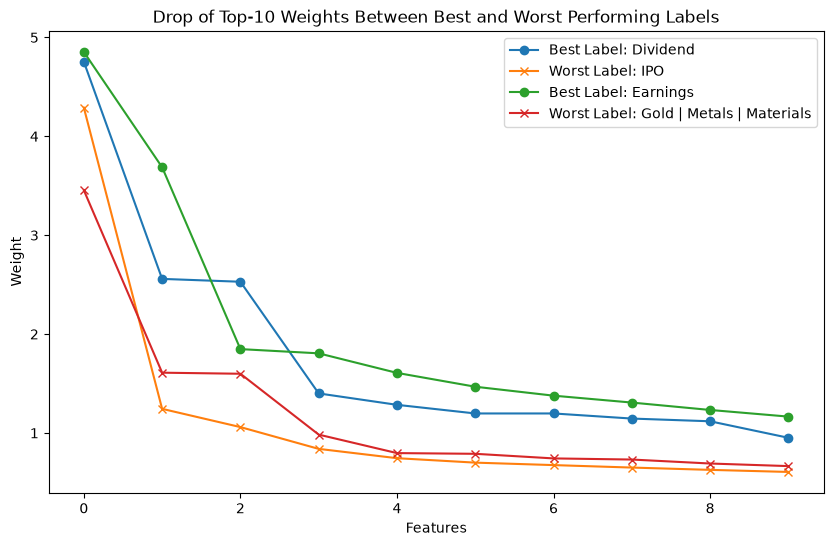

In [254]:
import matplotlib.pyplot as plt

# plot the drop of the top-10 weight between the best and worst performing labels
plt.figure(figsize=(10, 6))
plt.xlabel('Features')
plt.ylabel('Weight')
plt.title('Drop of Top-10 Weights Between Best and Worst Performing Labels')

# Plot
for i in range(2):
    plt.plot(range(10), best_weights[i], marker='o', label=f'Best Label: {best_labels_name[i]}')
    plt.plot(range(10), worst_weights[i], marker='x', label=f'Worst Label: {worst_labels_name[i]}')

# Legend
plt.legend()

plt.show()

In [255]:
# Check frequency of the word 'prices' in the training data grouped by each label
train['prices_count'] = train['text'].apply(lambda x: x.split().count('earnings'))
prices_count_by_label = train.groupby('label')['prices_count'].sum()
prices_count_by_label

label
Analyst Update                  22
Company | Product News           4
Currencies                       1
Dividend                         0
Earnings                       650
Energy | Oil                     0
Fed | Central Banks              2
Financials                      64
General News | Opinion           5
Gold | Metals | Materials        0
IPO                              0
Legal | Regulation               0
M&A | Investments                2
Macro                           11
Markets                         80
Personnel Change                 0
Politics                         0
Stock Commentary                18
Stock Movement                  86
Treasuries | Corporate Debt      3
Name: prices_count, dtype: int64

In [256]:
# Count the label in the training data
train['label'].value_counts()

label
Company | Product News         3286
Stock Commentary               1988
Macro                          1455
General News | Opinion         1239
Earnings                        974
Politics                        864
Stock Movement                  800
Fed | Central Banks             685
Financials                      598
Personnel Change                478
M&A | Investments               455
Legal | Regulation              448
Energy | Oil                    445
Markets                         436
Dividend                        359
Analyst Update                  246
Treasuries | Corporate Debt     243
Currencies                      141
Gold | Metals | Materials        58
IPO                              42
Name: count, dtype: int64

In [ ]:
# Q5

# Re-evaluate the model with 200 stratified samples of the test data
SAMPLE_SIZE = 200

def stratified_sample(df, sample_size, random_state=42):
    if sample_size >= len(df):
        return df.copy()

    label_counts = df['label'].value_counts()
    exact_sample_counts = label_counts / len(df) * sample_size
    sample_counts = exact_sample_counts.astype(int)
    remaining = sample_size - sample_counts.sum()
    allocation_order = (exact_sample_counts - sample_counts).sort_values(ascending=False)
    sample_counts.loc[allocation_order.index[:remaining]] += 1

    sampled_df = pd.concat([df[df['label'] == label].sample(n=count, random_state=random_state) for label, count in sample_counts.items()])
    
    return sampled_df

data = stratified_sample(test, SAMPLE_SIZE)

x_sample = vectorizer.transform(data['text'])
y_sample = encoder.transform(data['label'])

pred = model.predict(x_sample)

In [258]:
print(classification_report(
    y_sample,
    pred,
    target_names=encoder.classes_,
    digits=3,
    zero_division=0
))

                             precision    recall  f1-score   support

             Analyst Update      0.500     0.667     0.571         3
     Company | Product News      0.795     0.756     0.775        41
                 Currencies      1.000     1.000     1.000         1
                   Dividend      1.000     1.000     1.000         5
                   Earnings      0.818     0.750     0.783        12
               Energy | Oil      1.000     1.000     1.000         7
        Fed | Central Banks      0.900     0.900     0.900        10
                 Financials      0.857     0.750     0.800         8
     General News | Opinion      0.591     0.812     0.684        16
  Gold | Metals | Materials      1.000     1.000     1.000         1
                        IPO      1.000     1.000     1.000         1
         Legal | Regulation      0.857     1.000     0.923         6
          M&A | Investments      0.714     0.833     0.769         6
                      Macro      